In [64]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.feature import canny
from scipy.ndimage import maximum_filter

In [65]:
class LinearHT:
    def __init__(self, img, aSteps, rSteps):
        self.img = img
        self.nAng = aSteps
        self.dAng = np.pi / self.nAng
        self.nRad = rSteps

        self.xCtr = img.shape[1] / 2.0
        self.yCtr = img.shape[0] / 2.0

        self.rMax = np.hypot(self.xCtr, self.yCtr)
        self.dRad = (2 * self.rMax) / self.nRad
        self.rOffset = self.nRad // 2

        self.houghArray = np.zeros((self.nRad, self.nAng), dtype=int)

        self.fillHoughAccumulator()

    def fillHoughAccumulator(self):
        for v in range(self.img.shape[0]):
            for u in range(self.img.shape[1]):
                if self.img[v, u] > 0:
                    self.doPixel(u, v)

    def doPixel(self, u, v):
        x = u - self.xCtr
        y = v - self.yCtr
        for a in range(self.nAng):
            theta = self.dAng * a
            rho = x * np.cos(theta) + y * np.sin(theta)
            rhos = np.linspace(-self.rMax, self.rMax, self.nRad)
            r_idx = np.searchsorted(rhos, rho)
            if 0 <= r_idx < self.nRad:
                self.houghArray[r_idx, a] += 1






In [66]:
def plot_top_hough_lines(ht, original_img, num_lines, filter_size, threshold_frac):

    acc = ht.houghArray
    thetas = np.linspace(0, np.pi, ht.nAng, endpoint=False)
    rhos = np.linspace(-ht.rMax, ht.rMax, ht.nRad)

    # Peak-Detektion
    threshold = int(threshold_frac * acc.max())
    neighborhood = maximum_filter(acc, size=filter_size)
    peaks = (acc == neighborhood) & (acc > threshold)
    coords = np.argwhere(peaks)
    values = [acc[tuple(coord)] for coord in coords]
    sorted_idx = np.argsort(values)[::-1][:num_lines]
    top_coords = coords[sorted_idx]

    # Plot Originalbild + Linien
    plt.figure(figsize=(6,6))
    plt.imshow(original_img, cmap='gray')
    ny, nx = original_img.shape
    xc, yc = nx / 2.0, ny / 2.0

    for r_idx, a_idx in top_coords:
        rho = rhos[r_idx]
        theta = thetas[a_idx]
        if np.sin(theta) != 0:
            u_vals = np.array([0, nx])
            v_vals = (rho - (u_vals - xc) * np.cos(theta)) / np.sin(theta) + yc
            plt.plot(u_vals, v_vals, 'r')
    plt.title(f"Top {num_lines} Linien")
    plt.axis('off')
    plt.show()


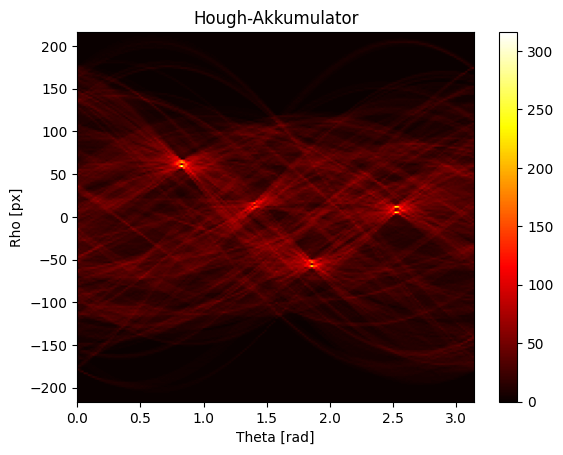

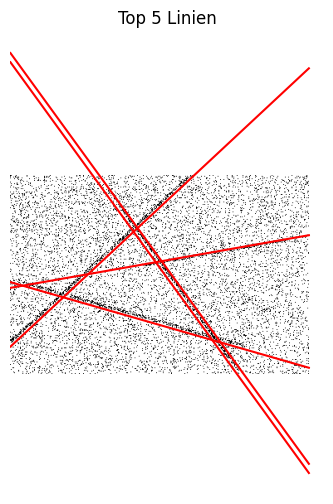

In [67]:
# Hough-Transform Parameter
canny_filter_sigma = 2.75
hough_aSteps = 180
hough_rSteps = 200

# 
num_lines = 5
filter_size = 5
threshold_frac = 0.5



image = imread("noisy-lines.tif", as_gray=True)
edges = canny(image, sigma=canny_filter_sigma)
binary_img = edges.astype(np.uint8)
# Hough-Transform berechnen
hough = LinearHT(binary_img, aSteps=hough_aSteps, rSteps=hough_rSteps)

# Optional: Hough-Akkumulator anzeigen
plt.imshow(hough.houghArray, cmap="hot", aspect='auto', extent=[0, np.pi, -hough.rMax, hough.rMax])
plt.xlabel("Theta [rad]")
plt.ylabel("Rho [px]")
plt.title("Hough-Akkumulator")
plt.colorbar()
plt.show()

plot_top_hough_lines(hough, image, num_lines=num_lines, filter_size=filter_size, threshold_frac=threshold_frac)
